<a href="https://colab.research.google.com/github/Adityanarayanjh/Corrosion_Rate/blob/main/mse656_project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_excel("Corrosion_Cleaned_Final.xlsx")


array([[<Axes: title={'center': '%Cr'}>, <Axes: title={'center': '%Ni'}>,
        <Axes: title={'center': '%Mo'}>, <Axes: title={'center': '%C'}>,
        <Axes: title={'center': '%Mn'}>],
       [<Axes: title={'center': '%Si'}>, <Axes: title={'center': '%Cu'}>,
        <Axes: title={'center': '%N'}>,
        <Axes: title={'center': 'temperature_C'}>,
        <Axes: title={'center': 'chloride_ppm'}>],
       [<Axes: title={'center': 'pH'}>,
        <Axes: title={'center': 'resistivity_ohm_m'}>,
        <Axes: title={'center': 'flow_rate_m_s'}>,
        <Axes: title={'center': 'relative_humidity_%'}>,
        <Axes: title={'center': 'exposure_days'}>],
       [<Axes: title={'center': 'PREN'}>,
        <Axes: title={'center': 'Cr_Ni_ratio'}>,
        <Axes: title={'center': 'log_chloride'}>,
        <Axes: title={'center': 'marine_severity_index'}>,
        <Axes: title={'center': 'relative_resistance_index'}>],
       [<Axes: title={'center': 'corrosion_rate_mm_per_year'}>, <Axes: >,
  

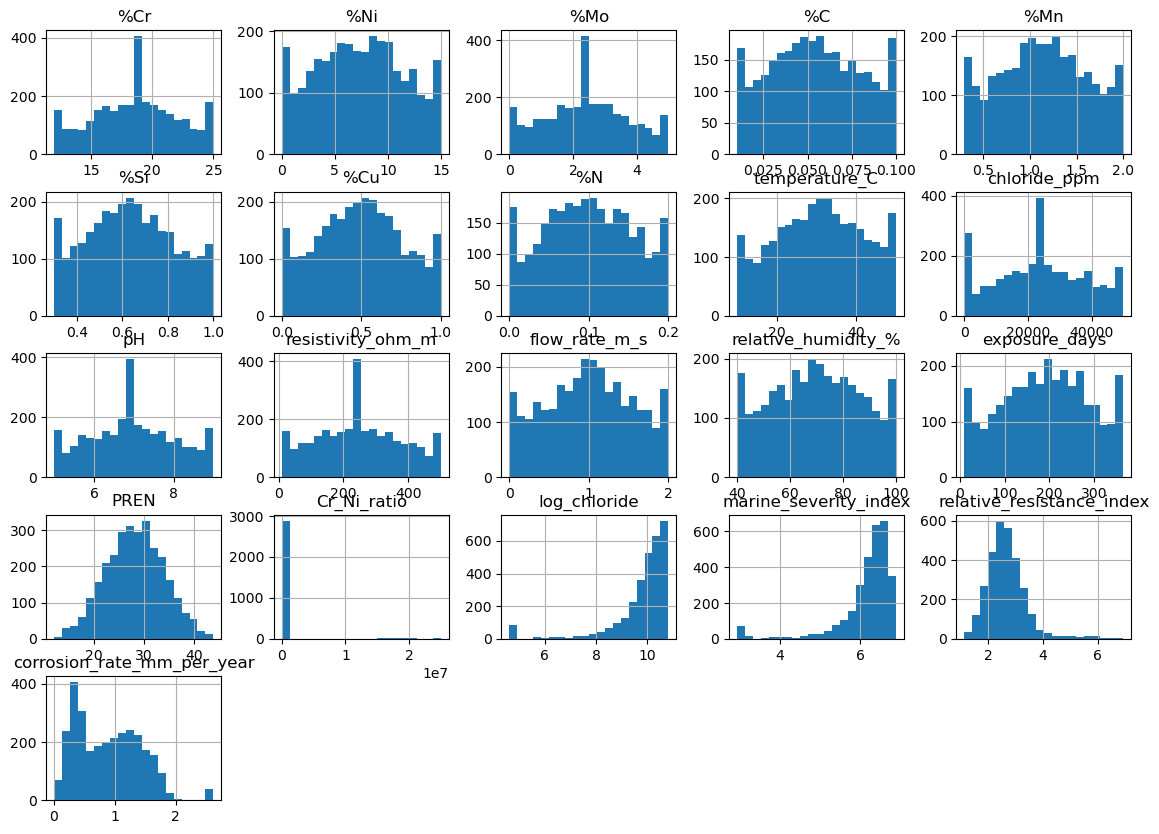

In [ ]:
df.hist(figsize=(14,10), bins=20)


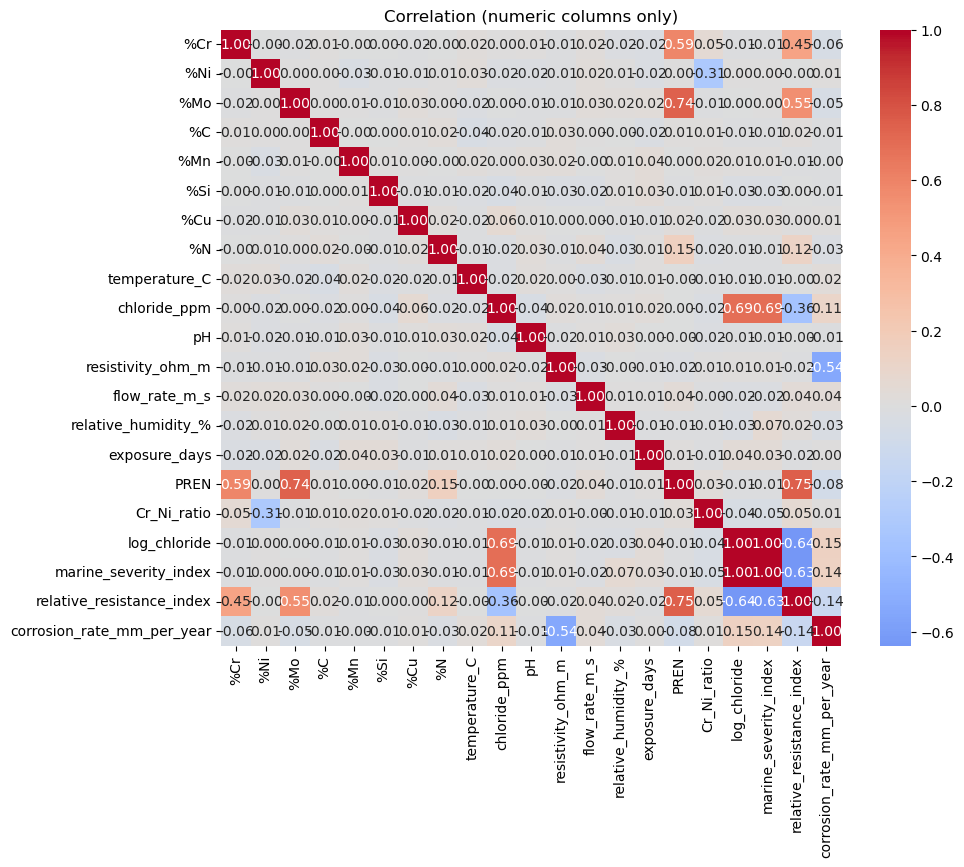

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title("Correlation (numeric columns only)")
plt.show()


<Axes: xlabel='PREN', ylabel='corrosion_rate_mm_per_year'>

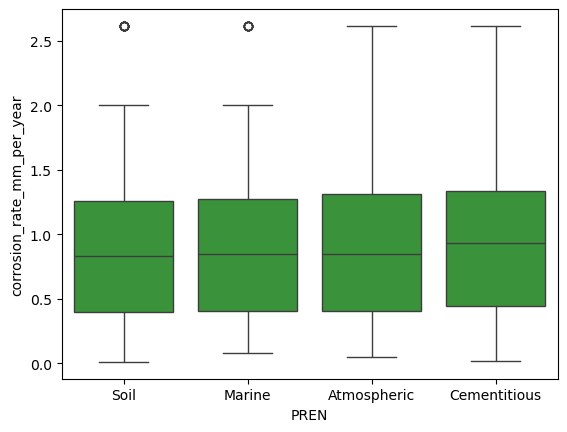

In [ ]:
sns.scatterplot(x='PREN', y='corrosion_rate_mm_per_year', data=df)
sns.scatterplot(x='log_chloride', y='corrosion_rate_mm_per_year', data=df)
sns.boxplot(x='environment', y='corrosion_rate_mm_per_year', data=df)


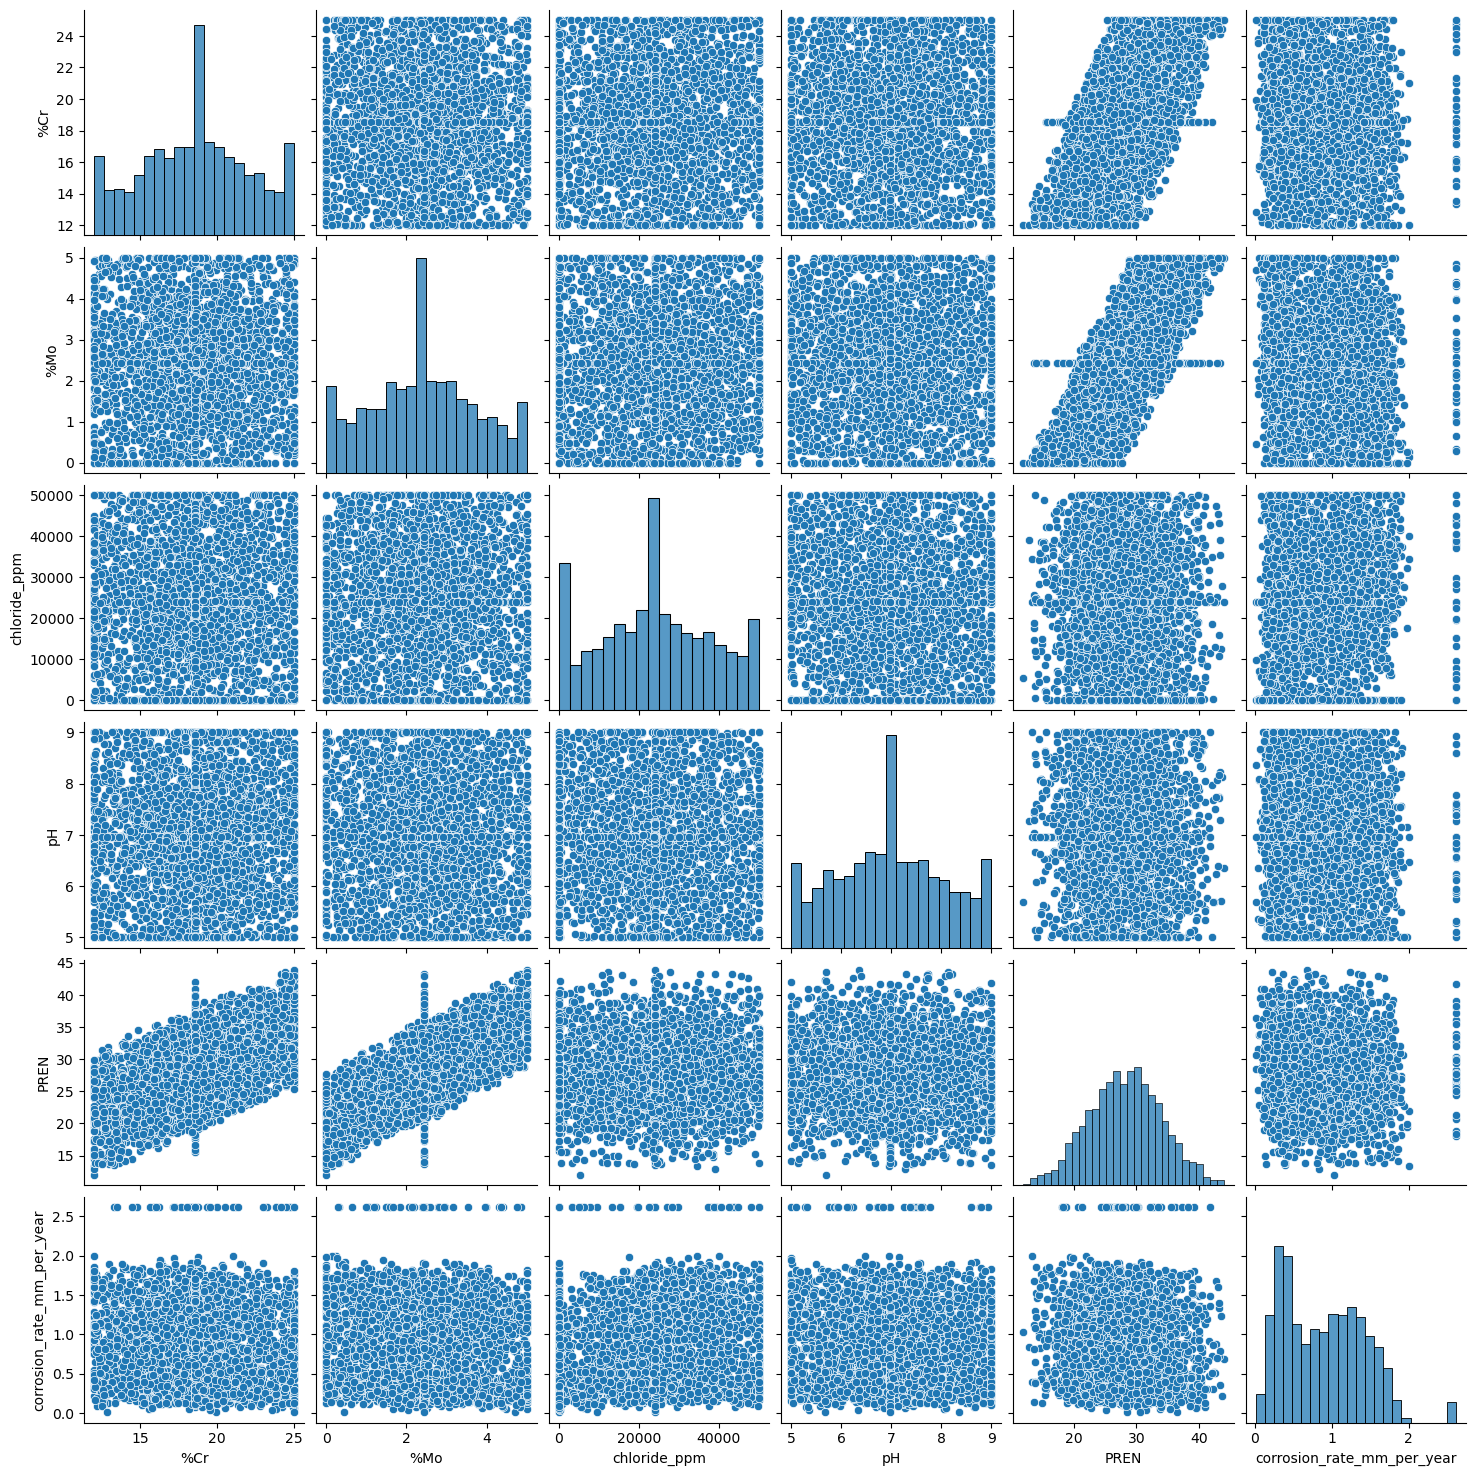

In [ ]:
sns.pairplot(df[['%Cr', '%Mo', 'chloride_ppm', 'pH', 'PREN', 'corrosion_rate_mm_per_year']])


Step 2: Feature Engineering & Selection

In [ ]:
import pandas as pd, numpy as np
df = pd.read_excel("Corrosion_Cleaned_Final.xlsx")

df["PREN"] = df["%Cr"] + 3.3 * df["%Mo"] + 16 * df["%N"]

df["log_chloride"] = np.log1p(df["chloride_ppm"])

df["OH_conc"] = 10 ** (df["pH"] - 14)
df["Cl_OH_ratio"] = df["chloride_ppm"] / (df["OH_conc"] + 1e-9)

df["marine_severity_index"] = 0.6 * df["log_chloride"] + 0.4 * (df["relative_humidity_%"] / 100)

df["temp_x_logCl"] = df["temperature_C"] * df["log_chloride"]

df["log_exposure_days"] = np.log1p(df["exposure_days"])
df["sqrt_exposure_days"] = np.sqrt(df["exposure_days"])


In [ ]:
df["Cr_Ni_ratio"] = df["%Cr"] / (df["%Ni"] + 1e-6)
df["Cr_Mo_ratio"] = df["%Cr"] / (df["%Mo"] + 1e-6)
df["Ni_Mo_ratio"] = df["%Ni"] / (df["%Mo"] + 1e-6)
df["CrxNi"] = df["%Cr"] * df["%Ni"]
df["CrxMo"] = df["%Cr"] * df["%Mo"]


In [ ]:
df["coating_bin"] = (df["coating"].astype(str).str.lower() == "yes").astype(int)

df["inv_resistivity"] = 1 / (df["resistivity_ohm_m"] + 1e-6)


In [ ]:
for c in ["log_chloride","PREN","temperature_C","pH"]:
    df[f"{c}_sq"] = df[c]**2


In [ ]:
df["chloride_bucket"] = pd.cut(
    df["chloride_ppm"],
    bins=[-1, 100, 1000, 5000, 20000, 1e9],
    labels=["very_low", "low", "moderate", "high", "very_high"]
)


In [ ]:
for g in ["material","environment"]:
    grp = df.groupby(g)["corrosion_rate_mm_per_year"]
    df[f"{g}_mean_rate"] = df[g].map(grp.mean())
    df[f"{g}_std_rate"]  = df[g].map(grp.std().fillna(0))


In [ ]:
df = pd.get_dummies(df, columns=["material","environment"], drop_first=True)
df.head()

,sample_id,coating,%Cr,%Ni,%Mo,%C,%Mn,%Si,%Cu,%N,...,environment_mean_rate,environment_std_rate,material_AISI316L,material_AISI410,material_AISI430,material_AISI444,material_Duplex2205,environment_Cementitious,environment_Marine,environment_Soil
0,N0802,No,16.540095,15.000000,2.381767,0.031064,0.577209,0.741409,0.203535,0.141515,...,0.879161,0.539249,False,False,False,True,False,False,False,True
1,N0191,No,16.802068,0.475785,3.027630,0.083193,1.439811,0.471953,0.613039,0.180427,...,0.886462,0.520598,False,True,False,False,False,False,True,False
2,N0818,Yes,21.836376,8.956516,1.217373,0.016021,1.183271,0.679382,0.639391,0.054905,...,0.886462,0.520598,False,False,False,True,False,False,True,False
3,S0252,No,24.532226,8.492710,2.448220,0.044766,1.022150,0.680384,0.047958,0.014174,...,0.885698,0.521220,False,False,False,False,True,False,False,False
4,N1506,Yes,16.776775,1.448785,3.663215,0.010000,1.629560,0.663917,0.863433,0.094992,...,0.886462,0.520598,False,False,False,False,False,False,True,False


In [ ]:
# outlier flag by IQR on target
Q1 = df["corrosion_rate_mm_per_year"].quantile(0.25)
Q3 = df["corrosion_rate_mm_per_year"].quantile(0.75)
IQR = Q3 - Q1
df["is_outlier_rate"] = ((df["corrosion_rate_mm_per_year"] < (Q1 - 1.5*IQR)) |
                         (df["corrosion_rate_mm_per_year"] > (Q3 + 1.5*IQR))).astype(int)

# missingness flags for columns you imputed earlier
for c in ["%Mo","pH","chloride_ppm"]:
    df[f"{c}_was_missing"] = df[c].isna().astype(int)


In [ ]:
df.to_excel("Corrosion_Featured.xlsx", index=False)
print(" Feature-engineered dataset created and saved as 'Corrosion_Featured.xlsx'")
print("Number of columns:", len(df.columns))


 Feature-engineered dataset created and saved as 'Corrosion_Featured.xlsx'
Number of columns: 59


In [ ]:
print(df.columns[:30].tolist())


['sample_id', 'coating', '%Cr', '%Ni', '%Mo', '%C', '%Mn', '%Si', '%Cu', '%N', 'temperature_C', 'chloride_ppm', 'pH', 'resistivity_ohm_m', 'flow_rate_m_s', 'relative_humidity_%', 'exposure_days', 'PREN', 'Cr_Ni_ratio', 'log_chloride', 'marine_severity_index', 'relative_resistance_index', 'corrosion_rate_mm_per_year', 'risk_level', 'source_reference', '_Unnamed_', 'Notes', 'OH_conc', 'Cl_OH_ratio', 'temp_x_logCl']


In [ ]:
df[['log_chloride','PREN','pH','coating_bin','corrosion_rate_mm_per_year']].corr()


,log_chloride,PREN,pH,coating_bin,corrosion_rate_mm_per_year
log_chloride,1.000000,-0.018503,-0.034603,-0.021431,0.080851
PREN,-0.018503,1.000000,-0.000964,0.024244,-0.077186
pH,-0.034603,-0.000964,1.000000,-0.024059,-0.005630
coating_bin,-0.021431,0.024244,-0.024059,1.000000,-0.658045
corrosion_rate_mm_per_year,0.080851,-0.077186,-0.005630,-0.658045,1.000000


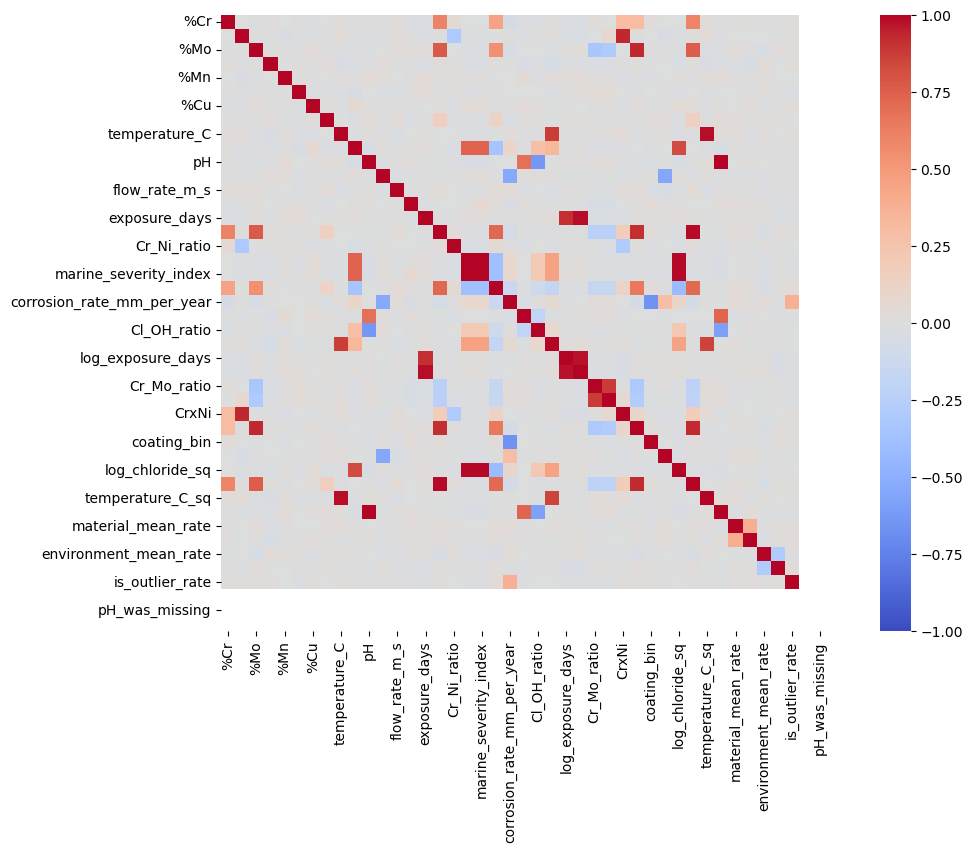

In [ ]:
import seaborn as sns, matplotlib.pyplot as plt

num_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(10,8))
sns.heatmap(num_df.corr(), cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.show()


In [ ]:
df[['PREN', 'corrosion_rate_mm_per_year']].corr()


,PREN,corrosion_rate_mm_per_year
PREN,1.000000,-0.077186
corrosion_rate_mm_per_year,-0.077186,1.000000
